In [47]:
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets 
from torchvision.transforms import ToTensor 


In [48]:
training_data = datasets.FashionMNIST(
    root= "data",
    train=True,
    download= True,
    transform=ToTensor(),
)

test_data = datasets.FashionMNIST(
    root= "data",
    train=False,
    download= True,
    transform=ToTensor(),
)

In [49]:
batch_size = 64
#create data loaders 
train_dataloader = DataLoader(training_data,batch_size=batch_size)
test_dataloader = DataLoader(test_data,batch_size = batch_size)

for X, y in test_dataloader :
    print(f"Shape of X [N , C , H , W]: {X.shape}")
    print(f"Shape of y : {y.shape} {y.dtype}")
    break 

Shape of X [N , C , H , W]: torch.Size([64, 1, 28, 28])
Shape of y : torch.Size([64]) torch.int64


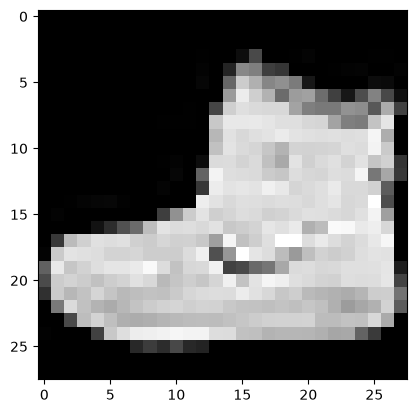

In [50]:
import torch 
import matplotlib.pyplot as plt 

def show_data(data):
    plt.imshow(data[0][0].squeeze(),cmap ="gray")
    plt.show()

show_data(training_data[0])

In [51]:
training_data[2][1]

0

In [52]:
#device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
device = "cpu"
print(f"Using {device} device")

# Define model
class NeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(28*28, 512),
            nn.ReLU(),
            nn.Linear(512, 512),
            nn.ReLU(),
            nn.Linear(512, 10)
        )

    def forward(self, x):
        x = self.flatten(x)
        logits = self.linear_relu_stack(x)
        return logits



Using cpu device


In [53]:

model = NeuralNetwork().to(device)
print(model)

NeuralNetwork(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=512, bias=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=10, bias=True)
  )
)


In [54]:
print(sum(p.numel() for p in model.parameters()))

669706


In [55]:
(1- 0.0879) * 1e-3

0.0009121

In [56]:
import torch
torch.softmax(model(training_data[0][0]),dim = 1)

tensor([[0.1018, 0.1031, 0.1023, 0.1003, 0.1030, 0.0922, 0.0921, 0.1021, 0.1060,
         0.0971]], grad_fn=<SoftmaxBackward0>)

In [57]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr = 1e-3)

In [58]:
def train(dataloader, model, loss_fn, optimizer):
    size = len(dataloader.dataset)
    model.train()
    for batch, (X, y) in enumerate(dataloader):
        X, y = X.to(device), y.to(device)

        # Compute prediction error
        pred = model(X)
        loss = loss_fn(pred, y)

        # Backpropagation
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        if batch % 100 == 0:
            loss, current = loss.item(), (batch + 1) * len(X)
            print(f"loss: {loss:>7f}  [{current:>5d}/{size:>5d}]")

In [59]:
def test(dataloader, model, loss_fn):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    model.eval()
    test_loss, correct = 0, 0
    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            pred = model(X)
            test_loss += loss_fn(pred, y).item()
            correct += (pred.argmax(1) == y).type(torch.float).sum().item()
    test_loss /= num_batches
    correct /= size
    print(f"Test Error: \n Accuracy: {(100*correct):>0.1f}%, Avg loss: {test_loss:>8f} \n")

In [62]:
epochs = 5
for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    train(train_dataloader, model, loss_fn, optimizer)
    test(test_dataloader, model, loss_fn)
print("Done!")

Epoch 1
-------------------------------
loss: 0.789976  [   64/60000]
loss: 0.859197  [ 6464/60000]
loss: 0.640029  [12864/60000]
loss: 0.842118  [19264/60000]
loss: 0.739839  [25664/60000]
loss: 0.732726  [32064/60000]
loss: 0.816561  [38464/60000]
loss: 0.799069  [44864/60000]
loss: 0.798486  [51264/60000]
loss: 0.754456  [57664/60000]
Test Error: 
 Accuracy: 72.4%, Avg loss: 0.755935 

Epoch 2
-------------------------------
loss: 0.752850  [   64/60000]
loss: 0.828657  [ 6464/60000]
loss: 0.608361  [12864/60000]
loss: 0.818339  [19264/60000]
loss: 0.718232  [25664/60000]
loss: 0.707146  [32064/60000]
loss: 0.791589  [38464/60000]
loss: 0.782797  [44864/60000]
loss: 0.775710  [51264/60000]
loss: 0.732675  [57664/60000]
Test Error: 
 Accuracy: 73.4%, Avg loss: 0.733381 

Epoch 3
-------------------------------
loss: 0.720327  [   64/60000]
loss: 0.801016  [ 6464/60000]
loss: 0.581351  [12864/60000]
loss: 0.798300  [19264/60000]
loss: 0.699588  [25664/60000]
loss: 0.685947  [32064/600

In [63]:
test(train_dataloader,model,loss_fn)

Test Error: 
 Accuracy: 77.0%, Avg loss: 0.661801 

